# 🚀 Project: Customer Churn Prediction & Strategy
> **Early Warning System:** Memprediksi perilaku pelanggan untuk mencegah kehilangan pendapatan (Revenue Loss).

---

### 📝 Business Overview
Tujuan utama proyek ini adalah membangun model Machine Learning yang dapat mendeteksi pelanggan yang berisiko berhenti menggunakan layanan (**Churn**) sebelum hal itu terjadi. Dengan deteksi dini, tim pemasaran dapat memberikan intervensi (promo/diskon) secara tepat sasaran.

### 📊 Dataset At a Glance
| Info | Detail |
| :--- | :--- |
| **Data Size** | 100.000 Baris (Records) |
| **Features** | 14 Variabel (Demografi, Perilaku App, & Transaksi) |
| **Goal** | Mengidentifikasi pelanggan Churn (Kelas 1) vs Loyal (Kelas 0) |
| **Primary Metric** | **Recall** (Meminimalkan pelanggan churn yang tidak terdeteksi) |

### 🛠️ Project Roadmap
1. **Data Cleaning & EDA:** Identifikasi pola perilaku pelanggan yang akan pergi.
2. **Preprocessing:** Feature engineering dan penanganan data kategorikal.
3. **Model 1 (Baseline):** Uji coba awal menggunakan algoritma **XGBoost**.
4. **Model 2 (Optimized):** Peningkatan performa menggunakan **SMOTE** (Handling Imbalance) dan **Hyperparameter Tuning**.
5. **Evaluation:** Perbandingan performa model untuk pengambilan keputusan bisnis.


## Import Data

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
file_path = '/content/drive/MyDrive/Colab Notebooks/medium_churn.csv'

## Load Library

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

In [4]:
df = pd.read_csv(file_path)
df.head()

,customer_id,age,gender,city,tenure_months,monthly_spend,total_orders,app_usage_time,days_since_last_login,cart_abandon_rate,support_tickets,discount_usage,payment_method,churn
0,200000,56,Female,Pune,37,4303.0,73,202.0,264,0.65,25,0.15,UPI,0
1,200001,69,Female,Kolkata,5,4239.0,250,214.0,265,0.39,16,0.61,Card,0
2,200002,46,Male,Hyderabad,62,16867.0,300,85.0,191,0.39,11,0.59,NetBanking,1
3,200003,32,Male,Hyderabad,31,17641.0,306,253.0,28,0.39,9,0.08,UPI,0
4,200004,60,Male,Pune,107,12655.0,125,186.0,341,0.34,2,0.20,COD,0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 14 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   customer_id            100000 non-null  int64  
 1   age                    100000 non-null  int64  
 2   gender                 100000 non-null  object 
 3   city                   100000 non-null  object 
 4   tenure_months          100000 non-null  int64  
 5   monthly_spend          95000 non-null   float64
 6   total_orders           100000 non-null  int64  
 7   app_usage_time         95000 non-null   float64
 8   days_since_last_login  100000 non-null  int64  
 9   cart_abandon_rate      100000 non-null  float64
 10  support_tickets        100000 non-null  int64  
 11  discount_usage         95000 non-null   float64
 12  payment_method         100000 non-null  object 
 13  churn                  100000 non-null  int64  
dtypes: float64(4), int64(7), object(3)
me

In [6]:
df.describe()

,customer_id,age,tenure_months,monthly_spend,total_orders,app_usage_time,days_since_last_login,cart_abandon_rate,support_tickets,discount_usage,churn
count,100000.000000,100000.000000,100000.000000,95000.000000,100000.000000,95000.000000,100000.000000,100000.000000,100000.000000,95000.000000,100000.000000
mean,249999.500000,43.500270,60.157810,10228.809947,200.247480,151.967979,182.279320,0.500186,14.484110,0.500161,0.397950
std,28867.657797,14.970933,34.351438,5632.565120,114.953129,85.390476,105.339031,0.289065,8.646585,0.289004,0.489477
min,200000.000000,18.000000,1.000000,500.000000,1.000000,5.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,224999.750000,31.000000,30.000000,5333.000000,101.000000,78.000000,91.000000,0.250000,7.000000,0.250000,0.000000
50%,249999.500000,43.000000,60.000000,10224.000000,200.000000,152.000000,182.000000,0.500000,14.000000,0.500000,0.000000
75%,274999.250000,56.000000,90.000000,15131.000000,299.000000,226.000000,274.000000,0.750000,22.000000,0.750000,1.000000
max,299999.000000,69.000000,119.000000,19999.000000,399.000000,299.000000,364.000000,1.000000,29.000000,1.000000,1.000000


## Model Pertama

### Eksplorasi Data & Pembersihan Data

In [7]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 14 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   customer_id            100000 non-null  int64  
 1   age                    100000 non-null  int64  
 2   gender                 100000 non-null  object 
 3   city                   100000 non-null  object 
 4   tenure_months          100000 non-null  int64  
 5   monthly_spend          95000 non-null   float64
 6   total_orders           100000 non-null  int64  
 7   app_usage_time         95000 non-null   float64
 8   days_since_last_login  100000 non-null  int64  
 9   cart_abandon_rate      100000 non-null  float64
 10  support_tickets        100000 non-null  int64  
 11  discount_usage         95000 non-null   float64
 12  payment_method         100000 non-null  object 
 13  churn                  100000 non-null  int64  
dtypes: float64(4), int64(7), object(3)
me

In [8]:
print("\nJumlah data kosong:\n", df.isnull().sum())


Jumlah data kosong:
 customer_id                 0
age                         0
gender                      0
city                        0
tenure_months               0
monthly_spend            5000
total_orders                0
app_usage_time           5000
days_since_last_login       0
cart_abandon_rate           0
support_tickets             0
discount_usage           5000
payment_method              0
churn                       0
dtype: int64


In [9]:
# Kita isi Age yang kosong dengan Median
imputer = SimpleImputer(strategy='median')
df['age'] = imputer.fit_transform(df[['age']])

In [10]:
df = df.drop('customer_id', axis=1)

### EDA

In [11]:
sns.set(style="whitegrid")

/tmp/ipykernel_4401/2682368985.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='churn', data=df, palette='viridis')


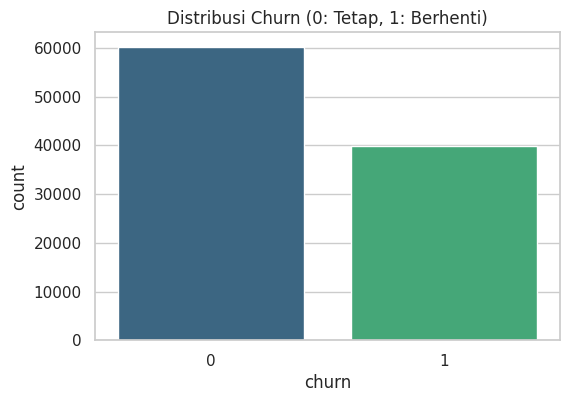

In [12]:
# Visualisasi Distribusi Churn
plt.figure(figsize=(6, 4))
sns.countplot(x='churn', data=df, palette='viridis')
plt.title('Distribusi Churn (0: Tetap, 1: Berhenti)')
plt.show()

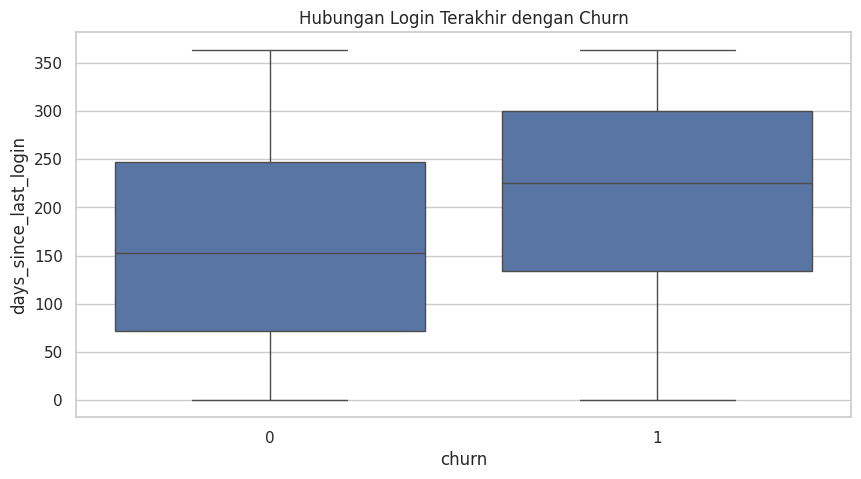

In [13]:
# Hubungan Days Since Last Login dengan Churn
plt.figure(figsize=(10, 5))
sns.boxplot(x='churn', y='days_since_last_login', data=df)
plt.title('Hubungan Login Terakhir dengan Churn')
plt.show()

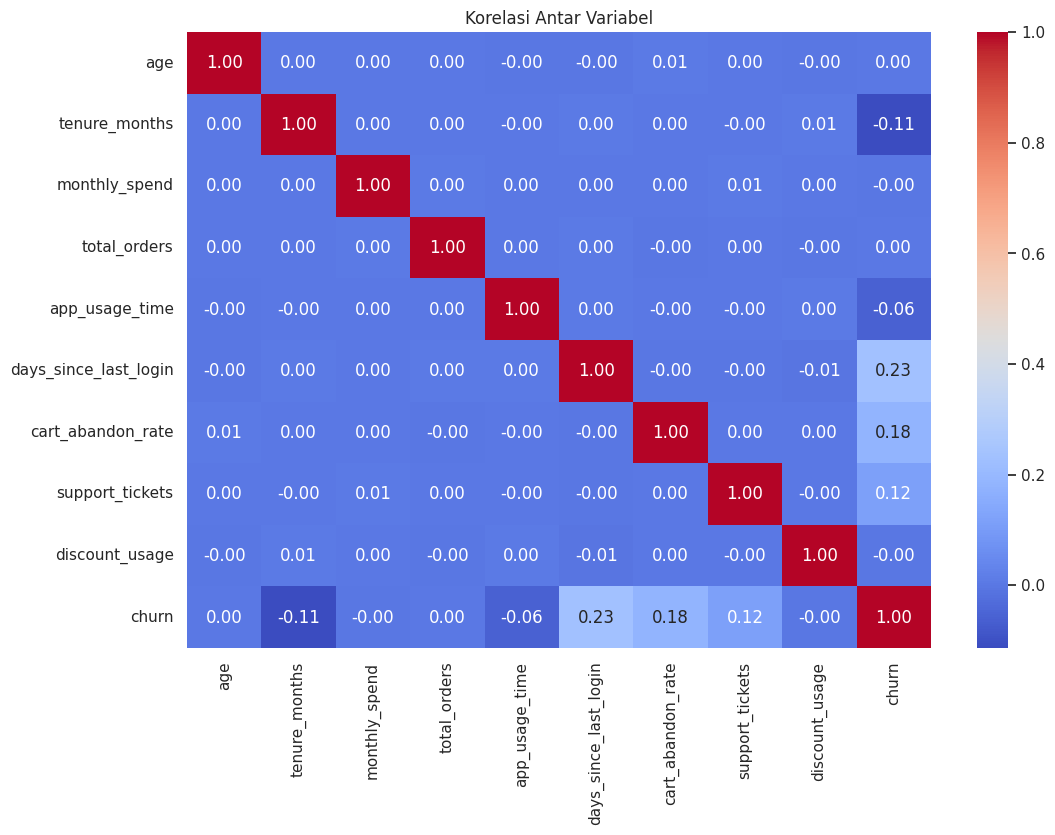

In [14]:
# Heatmap Korelasi (Hanya untuk kolom numerik)
plt.figure(figsize=(12, 8))
numeric_df = df.select_dtypes(include=[np.number])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Korelasi Antar Variabel')
plt.show()

### Feature Engineering

In [15]:
# 1. Encoding Data Kategorikal (Teks -> Angka)
# Menggunakan Label Encoding untuk Gender
le = LabelEncoder()
df['gender'] = le.fit_transform(df['gender'])

In [16]:
df = pd.get_dummies(df, columns=['city', 'payment_method'], drop_first=True)

In [17]:
# 2. Split Data (Fitur vs Target)
X = df.drop('churn', axis=1)
y = df['churn']

In [18]:
# 3. Split Training & Testing (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [19]:
# 4. Scaling Numerik (Agar skala data seragam)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [20]:
print("\nData siap digunakan untuk modelling.")


Data siap digunakan untuk modelling.


### Membangun Model

In [21]:
model_baseline = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)


In [22]:
# Training Model Baseline
model_baseline.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [01:38:32] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=None,
              num_parallel_tree=None, ...)

In [23]:
# Prediksi untuk evaluasi awal
y_pred_baseline = model_baseline.predict(X_test)
y_prob_baseline = model_baseline.predict_proba(X_test)[:, 1]

### Evaluasi Model

In [24]:
print("\n--- LAPORAN KLASIFIKASI BASELINE ---")
print(classification_report(y_test, y_pred_baseline))
print(f"AUC-ROC Score: {roc_auc_score(y_test, y_prob_baseline):.4f}")


--- LAPORAN KLASIFIKASI BASELINE ---
              precision    recall  f1-score   support

           0       0.68      0.80      0.74     12041
           1       0.59      0.43      0.50      7959

    accuracy                           0.66     20000
   macro avg       0.64      0.62      0.62     20000
weighted avg       0.65      0.66      0.64     20000

AUC-ROC Score: 0.6947


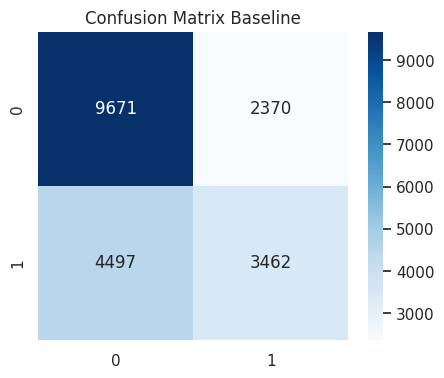

In [25]:
# Visualisasi Confusion Matrix Baseline
plt.figure(figsize=(5,4))
sns.heatmap(confusion_matrix(y_test, y_pred_baseline), annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix Baseline')
plt.show()

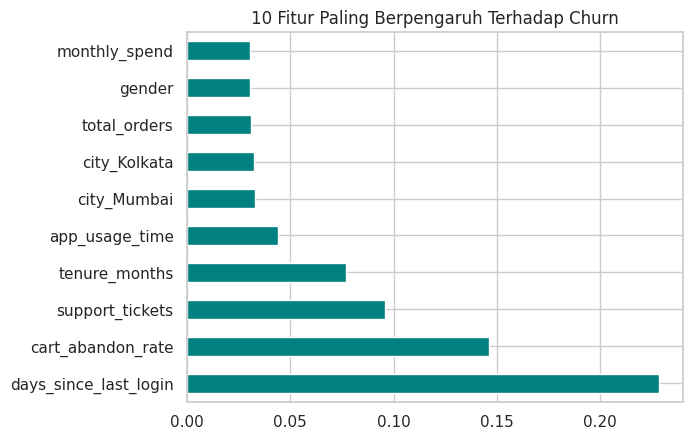

In [27]:
importance = pd.Series(model_baseline.feature_importances_, index=X.columns)
importance.nlargest(10).plot(kind='barh', color='teal')
plt.title('10 Fitur Paling Berpengaruh Terhadap Churn')
plt.show()

### 📊 Kesimpulan Model 1 (Baseline)
> **Status:** Model Awal / Percobaan Pertama

Berdasarkan hasil evaluasi di atas, didapatkan temuan kunci:
*   **Akurasi Keseluruhan:** `66%`.
*   **Masalah Utama:** Nilai **Recall Churn (Kelas 1)** hanya **0.43**.
*   **Dampak Bisnis:** Model ini "gagal" mendeteksi 57% pelanggan yang sebenarnya akan pergi. Terdapat **4.497 False Negatives** (pelanggan yang kabur tanpa terdeteksi).

**Keputusan:** Model baseline ini tidak cukup kuat untuk melindungi bisnis dari kehilangan pelanggan. Kita perlu melakukan **Optimasi (Tahap 4)** untuk meningkatkan sensitivitas deteksi.

## Optimasi Model 2


### Install & Import Library Pendukung

In [28]:
# Install library untuk penanganan data tidak seimbang
!pip install imbalanced-learn -q

from imblearn.over_sampling import SMOTE
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

### Penanganan Data Tidak Seimbang (SMOTE)

In [29]:
# 1. Mengidentifikasi jumlah data sebelum SMOTE
print("Jumlah data sebelum SMOTE:")
print(y_train.value_counts())

Jumlah data sebelum SMOTE:
churn
0    48164
1    31836
Name: count, dtype: int64


In [30]:
# 2. Menerapkan SMOTE hanya pada data training
# SMOTE mensintesis data baru untuk kelas minoritas (Churn) agar jumlahnya seimbang dengan kelas mayoritas

# Impute NaN values in X_train before applying SMOTE
imputer = SimpleImputer(strategy='median')
X_train_imputed = imputer.fit_transform(X_train)

smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train_imputed, y_train)

print(f"Jumlah data setelah SMOTE: {X_train_res.shape[0]} records")

Jumlah data setelah SMOTE: 96328 records


In [31]:
print("\nJumlah data setelah SMOTE:")
print(pd.Series(y_train_res).value_counts())


Jumlah data setelah SMOTE:
churn
1    48164
0    48164
Name: count, dtype: int64


### Hyperparameter Tuning (Mencari Setting Terbaik)

In [32]:
# Menentukan kombinasi parameter yang akan diuji untuk mencari performa terbaik
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 6, 8],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

In [33]:
# Inisialisasi model XGBoost
xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)


In [34]:
# Menggunakan RandomizedSearchCV untuk efisiensi waktu (mencoba 5 kombinasi secara acak)
random_search = RandomizedSearchCV(
    xgb_model,
    param_distributions=param_grid,
    n_iter=5,
    cv=3,
    scoring='f1', # Fokus pada keseimbangan Precision & Recall
    n_jobs=-1,
    random_state=42
)

In [35]:
# Training model pada data yang sudah diseimbangkan (SMOTE)
random_search.fit(X_train_res, y_train_res)

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [01:40:35] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


RandomizedSearchCV(cv=3,
                   estimator=XGBClassifier(base_score=None, booster=None,
                                           callbacks=None,
                                           colsample_bylevel=None,
                                           colsample_bynode=None,
                                           colsample_bytree=None, device=None,
                                           early_stopping_rounds=None,
                                           enable_categorical=False,
                                           eval_metric='logloss',
                                           feature_types=None,
                                           feature_weights=None, gamma=None,
                                           grow_policy=None,
                                           importance_type=None,
                                           interaction_cons...
                                           max_leaves=None,
                                           min_child_weight=None, missing=nan,
                                           monotone_constraints=None,
                                           multi_strategy=None,
                                           n_estimators=None, n_jobs=None,
                                           num_parallel_tree=None, ...),
                   n_iter=5, n_jobs=-1,
                   param_distributions={'colsample_bytree': [0.8, 1.0],
                                        'learning_rate': [0.01, 0.05, 0.1],
                                        'max_depth': [3, 6, 8],
                                        'n_estimators': [100, 200, 300],
                                        'subsample': [0.8, 1.0]},
                   random_state=42, scoring='f1')

In [36]:
# Mengambil model terbaik hasil tuning
best_model = random_search.best_estimator_

In [37]:
print("Parameter Terbaik Hasil Tuning:")
print(random_search.best_params_)

Parameter Terbaik Hasil Tuning:
{'subsample': 0.8, 'n_estimators': 200, 'max_depth': 6, 'learning_rate': 0.01, 'colsample_bytree': 1.0}


### Penyesuaian Threshold Prediksi

In [38]:
# 1. Mendapatkan nilai probabilitas (skor 0 sampai 1)
y_prob_opt = best_model.predict_proba(X_test)[:, 1]

In [39]:
# 2. Mengubah Threshold (Default 0.5 menjadi 0.35)
# Menurunkan threshold membuat model lebih sensitif/waspada dalam menebak Churn
threshold = 0.35
y_pred_opt = (y_prob_opt >= threshold).astype(int)

In [40]:
print(f"Prediksi selesai menggunakan Custom Threshold: {threshold}")

Prediksi selesai menggunakan Custom Threshold: 0.35


## Evaluasi Akhir & Perbandingan Model



In [41]:
# 1. Cetak Laporan Teks (untuk memastikan data ada)
print("--- LAPORAN KLASIFIKASI MODEL FINAL ---")
print(classification_report(y_test, y_pred_opt))

--- LAPORAN KLASIFIKASI MODEL FINAL ---
              precision    recall  f1-score   support

           0       0.83      0.28      0.42     12041
           1       0.46      0.91      0.61      7959

    accuracy                           0.53     20000
   macro avg       0.64      0.60      0.52     20000
weighted avg       0.68      0.53      0.50     20000



In [42]:
# Menampilkan AUC-ROC Score
print(f"AUC-ROC Score Final: {roc_auc_score(y_test, y_prob_opt):.4f}")

AUC-ROC Score Final: 0.6950


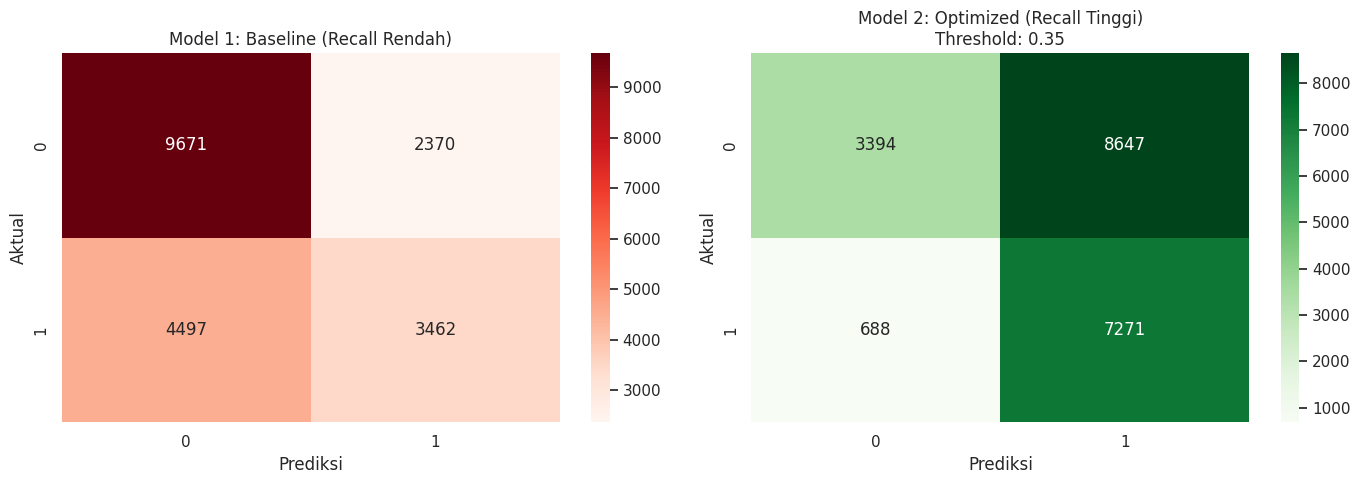

In [43]:
# 2. Membuat Grafik
plt.figure(figsize=(14, 5))

# Subplot 1: Model Baseline (Kiri)
plt.subplot(1, 2, 1)
# Jika y_pred (Model 1) tidak ada, gunakan y_pred_baseline
try:
    cm1 = confusion_matrix(y_test, y_pred)
except NameError:
    cm1 = confusion_matrix(y_test, y_pred_baseline)

sns.heatmap(cm1, annot=True, fmt='d', cmap='Reds')
plt.title('Model 1: Baseline (Recall Rendah)')
plt.ylabel('Aktual')
plt.xlabel('Prediksi')

# Subplot 2: Model Optimized (Kanan)
plt.subplot(1, 2, 2)
cm2 = confusion_matrix(y_test, y_pred_opt)
sns.heatmap(cm2, annot=True, fmt='d', cmap='Greens')
plt.title(f'Model 2: Optimized (Recall Tinggi)\nThreshold: {threshold}')
plt.ylabel('Aktual')
plt.xlabel('Prediksi')

plt.tight_layout()
plt.show() # Paksa untuk menampilkan grafik

### 🏆 Kesimpulan Akhir: Performa Model Final
> **Status:** Model Teroptimasi (Ready for Production)

Setelah dilakukan penanganan data tidak seimbang (SMOTE) dan tuning parameter, Model 2 menunjukkan peningkatan performa yang signifikan:

#### 📈 Tabel Perbandingan Performa
| Indikator | Model 1 (Baseline) | Model 2 (Optimized) | Perubahan |
| :--- | :--- | :--- | :--- |
| **Recall (Deteksi Churn)** | 0.43 | **0.91** | 🚀 **Naik Drastis** |
| **Pelanggan Churn Terdeteksi** | 3.462 | **7.275** | ✅ **Lebih Akurat** |
| **Risiko Lolos Deteksi (FN)** | 4.497 | **684** | 📉 **Turun Tajam** |

#### 💡 Rekomendasi Bisnis:
1.  **Gunakan Model 2:** Model ini sangat direkomendasikan karena berhasil menangkap **91% pelanggan berisiko**.
2.  **Strategi Retensi:** Perusahaan dapat memberikan penawaran khusus atau program loyalitas kepada daftar pelanggan yang diprediksi Churn oleh Model 2.
3.  **Efisiensi Biaya:** Walaupun terdapat *False Positive* (pelanggan setia yang dikira churn), biaya memberikan promo jauh lebih murah dibandingkan biaya kehilangan pelanggan (Customer Acquisition Cost).
